# 🟥1.Answer the questions from the introduction

## 🟥1.1 What is leave-one-out? Provide limitations and strengths.

## Leave-One-Out Cross-Validation (LOOCV)

## Определение

**Leave-One-Out** (LOO) — это частный случай кросс-валидации, при котором количество фолдов ($k$) равно количеству наблюдений в выборке ($n$).

На каждой итерации:
- **Обучение:** на $n-1$ объекте (все, кроме одного)
- **Валидация:** на 1 оставшемся объекте

Процесс повторяется $n$ раз, каждый объект по одному разу выступает в роли тестового.

$$ \text{Ошибка LOOCV} = \frac{1}{n} \sum_{i=1}^{n} L\left(y_i, \hat{f}^{(-i)}(x_i)\right) $$

где:
- $\hat{f}^{(-i)}$ — модель, обученная без $i$-го объекта
- $L$ — функция потерь (MSE, Accuracy и т.д.)

---

## Сильные стороны (Strengths)

| № | Преимущество | Пояснение |
|---|--------------|-----------|
| 1 | **Минимальное смещение (low bias)** | Модель обучается почти на всех данных ($n-1$), поэтому оценка качества близка к обучению на полной выборке |
| 2 | **Детерминированность** | Результат всегда одинаков для одного и того же набора данных (в отличие от случайной $k$-fold) |
| 3 | **Максимальное использование данных** | Каждый объект участвует в обучении $n-1$ раз, а в тесте — 1 раз |
| 4 | **Полезна для малых выборок** | Если данных мало ($n < 50$), каждый объект ценен, и LOO использует их максимально эффективно |

---

## Ограничения (Limitations)

| № | Ограничение | Пояснение |
|---|-------------|-----------|
| 1 | **Высокая вычислительная стоимость** | Нужно обучить модель $n$ раз. Если $n = 10\,000$ и обучение занимает 1 секунду → более 2.5 часов |
| 2 | **Большая дисперсия оценки** | Результаты на разных итерациях сильно коррелируют (обучающие выборки почти одинаковы). Оценка может быть нестабильной |
| 3 | **Неприменим для некоторых моделей** | Для моделей, которые требуют одинакового размера обучающей выборки (например, некоторые нейросети с фиксированным batch size) |
| 4 | **Риск переобучения при оценке** | При большом количестве признаков ($p \gg n$) модель может идеально запомнить данные, и LOO покажет завышенное качество |

---

## Сравнение с $k$-fold CV

| Характеристика | LOOCV | $k$-fold CV ($k=5$ или $10$) |
|----------------|-------|-------------------------------|
| Количество обучений | $n$ | $k$ |
| Вычислительная сложность | $O(n \cdot T_{\text{train}})$ | $O(k \cdot T_{\text{train}})$ |
| Смещение (bias) | Минимальное | Небольшое |
| Дисперсия (variance) | Высокая | Низкая |
| Для каких выборок | $n < 500$ | Любых |

---

## Когда использовать LOOCV?

###  **Хорошо подходит:**
- Очень маленькие выборки ($n < 100$)
- Быстрые модели (линейная регрессия, наивный Байес)
- Когда важна детерминированность результата

###  **Не подходит:**
- Большие данные ($n > 1000$)
- Медленные модели (глубокое обучение, ансамбли)
- Когда нужно быстро оценить качество

---

## Формула для линейной регрессии (частный случай)

Для линейной регрессии LOOCV можно вычислить **без переобучения** через формулу PRESS (Predicted Residual Sum of Squares):

$$ \text{PRESS} = \sum_{i=1}^{n} \left( \frac{e_i}{1 - h_{ii}} \right)^2 $$

где:
- $e_i$ — остаток $i$-го объекта при обучении на всех данных
- $h_{ii}$ — коэффициент влияния (leverage) $i$-го объекта

Это делает LOOCV для линейной регрессии быстрым даже при больших $n$.

---

## Итог

| Критерий | LOOCV |
|----------|-------|
| Суть | Каждый объект по одному разу в тесте |
| Количество итераций | $n$ |
| Смещение | Низкое  |
| Дисперсия | Высокая  |
| Скорость | Медленно (кроме линейной регрессии) |
| Лучше всего для | Маленьких выборок |

##  🟥1.2. How do Grid Search, Randomized Grid Search, and Bayesian optimization work?

## Методы оптимизации гиперпараметров

## Общее понятие

**Гиперпараметры** — это параметры модели, которые не обучаются на данных, а задаются до начала обучения (например, `alpha` в Lasso, `max_depth` в дереве решений, `C` в SVM).

Задача оптимизации гиперпараметров:

$$ \theta^* = \arg\min_{\theta \in \Theta} \mathcal{L}(\text{model}_\theta, \text{data}_{val}) $$

где:
- $\theta$ — набор гиперпараметров
- $\Theta$ — пространство поиска
- $\mathcal{L}$ — функция потерь на валидации

---

## 1. Grid Search (Полный перебор)

### Принцип работы

Задаётся **дискретная сетка** возможных значений для каждого гиперпараметра. Алгоритм перебирает **все возможные комбинации**.

### Пример

```python
param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'max_depth': [3, 5, 7, 9]
}
# Всего комбинаций: 4 × 4 = 16

### Randomized Search (Случайный поиск)

**Как работает:**

Вы задаёте не конкретные значения, а диапазоны:

- `learning_rate` от `0.001` до `1.0`
- `depth` от `2` до `10$

Алгоритм выбирает случайно, например, $N$ комбинаций внутри этих диапазонов. Каждая комбинация случайная, независимая.

**Разница с Grid:**

- **Grid Search** проверяет все варианты «как есть», по сетке.
- **Randomized Search** берёт случайные точки внутри диапазона.

**Когда лучше:**  
Параметров много ($d \ge 5$), потому что вы сами выбираете, сколько итераций потратить — хоть 30, хоть 200. Grid Search заставляет перебирать всё, что приводит к комбинаторному взрыву.

---

### Bayesian Optimization (Байесовская оптимизация)

**Как работает:**

Алгоритм учится на ошибках. Он не перебирает всё и не тыкает пальцем в небо.

**Процесс:**

1. Проверяет $n$ случайных комбинаций (например, $n = 5$), запоминает результат.
2. Строит внутреннюю карту («здесь было плохо, здесь средне, а тут хорошо»).
3. Выбирает следующую комбинацию туда, где, по его мнению, может быть ещё лучше (или где он ещё не пробовал и есть риск, но вдруг повезёт).
4. Проверяет.
5. Обновляет карту.
6. Повторяет шаги 2–5 заданное количество раз (например, 20–100).

**Почему это умно:**

- Не тратит время на заведомо плохие области.
- Использует историю, чтобы решать, куда идти дальше.
- Находит хорошие параметры за меньшее количество итераций, чем случайный поиск.

**Цена:**  
Сложнее в реализации, но библиотеки (Optuna, Hyperopt) уже всё сделали.

## 🟥1.3 Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.

## Feature Selection Methods: Обзор и объяснение

## 1. Классификация методов отбора признаков

Все методы делятся на три типа:

| Тип | Принцип | Примеры | Скорость | Учёт взаимодействий |
|-----|---------|---------|----------|---------------------|
| **Filter** | Статистическая оценка ДО обучения | Pearson, Chi2, Info Gain | Быстро | Нет |
| **Wrapper** | Оценка через обучение модели | RFE, Forward/Backward | Медленно | Да |
| **Embedded** | Отбор ВНУТРИ процесса обучения | Lasso, Random Forest | Средне | Частично |

---

## 2. Pearson (коэффициент корреляции Пирсона)

- **Для каких данных:** Непрерывные (числовые) признаки и непрерывная целевая переменная
- **Тип задачи:** Регрессия
- **Что измеряет:** Линейную связь между двумя переменными
- **Диапазон:** от –1 до +1
    - `+1`: идеальная прямая связь (больше X → больше Y)
    - `–1`: идеальная обратная связь (больше X → меньше Y)
    - `0`: линейной связи нет (возможна нелинейная)
- **Отбор признаков:** Берём признаки с |r| близким к 1

---

## 3. Chi2 (Хи-квадрат)

- **Для каких данных:** Категориальные (дискретные) признаки и категориальная целевая переменная
- **Тип задачи:** Классификация
- **Что измеряет:** Статистическую зависимость (связаны ли признаки)
- **Как работает:**
    1. Строится таблица сопряжённости (реальные частоты)
    2. Строится ожидаемая таблица (если бы признаки были независимы)
    3. Chi2 = сумма (реальная − ожидаемая)² / ожидаемая
- **Диапазон:** от 0 до +∞ (безразмерная величина)
- **Интерпретация:** Чем больше Chi2, тем сильнее зависимость (признак важнее)
- **Отбор признаков:** Ранжируем признаки по убыванию Chi2, берём топ-K

---

## 4. Lasso (L1-регуляризация)

- **Тип метода:** Embedded (встроенный)
- **Полное название:** Least Absolute Shrinkage and Selection Operator
- **Суть:** Линейная модель, которая добавляет штраф на сумму модулей коэффициентов

$$ Loss = MSE + \alpha \cdot \sum |w_i| $$

- **Главное свойство:** Разреживание весов (sparsity) — обнуляет коэффициенты неважных признаков
- **Параметр alpha (λ):**
    - Маленький alpha → почти обычная регрессия
    - Большой alpha → агрессивное сжатие, многие коэффициенты = 0
- **Отбор признаков:** При увеличении alpha первыми обнуляются самые маленькие по модулю коэффициенты
- **Преимущество:** Модель сама решает, какие признаки удалить, без внешнего перебора

---

## 5. Permutation Significance (Важность перестановкой)

- **Тип метода:** Model-agnostic (не зависит от модели)
- **Суть:** Оценить, насколько упадёт качество модели, если случайно перемешать значения одного признака

### Алгоритм:
1. Обучить модель, запомнить базовое качество (Accuracy, R², etc.)
2. Для каждого признака:
    - Перемешать (shuffle) значения этого признака (разорвать связь с целевой переменной)
    - Вычислить качество на перемешанных данных
    - `Важность = Базовое_качество − Качество_после_перемешивания`
3. Вернуть исходный порядок признаков

### Интерпретация:
- **Важность >> 0** → признак важный (модель без него сильно просела)
- **Важность ≈ 0** → признак бесполезный
- **Важность < 0** → признак токсичный / шумовой (после удаления качество выросло)

---

## 6. SHAP (SHapley Additive exPlanations)

- **Тип метода:** Model-agnostic, локальная интерпретация
- **Что даёт:** Раскладывает предсказание для **конкретного объекта** на вклады каждого признака

### Основная формула (идея):
$$ \text{Предсказание} = \text{Базовое значение} + \sum \text{Вклады\_признаков} $$

- **Базовое значение** = среднее предсказание модели по всем данным
- **Сумма вкладов всех признаков** = Предсказание − Базовое значение

### Как считается (упрощённо):
SHAP перебирает все возможные комбинации признаков, смотрит, как меняется предсказание при добавлении / удалении признака, и усредняет его вклад.

### Пример:
- Средняя цена квартиры (по всем данным) = 5 млн
- Модель предсказала для конкретной квартиры = 7 млн
- SHAP говорит:
    - Площадь: +1.5 млн
    - Район: +0.8 млн
    - Этаж: +0.2 млн
    - Состояние (ремонт): −0.5 млн
    - **Итого: 5 + 1.5 + 0.8 + 0.2 − 0.5 = 7 млн**

### Для чего использовать:
- Объяснить **конкретное решение** модели менеджеру или клиенту
- Отладка модели (почему модель ошиблась на этом объекте)
- Выявление неожиданных зависимостей

---

## Итоговая таблица выбора метода

| Задача | Какой метод |
|--------|--------------|
| Быстро отфильтровать признаки до обучения (непрерывные) | **Pearson** |
| Быстро отфильтровать признаки до обучения (категории) | **Chi2** |
| Модель сама должна удалить ненужные признаки | **Lasso** |
| Оценить важность признаков для любой уже обученной модели | **Permutation** |
| Объяснить одно конкретное предсказание | **SHAP** |


# 🟧2.Introduction — do all the preprocessing from the previous lesson

## 🟧2.1 Read all the data.

## ❗️Imports 

In [56]:
import pandas as pd
import re
from collections import Counter
import random
import numpy as np
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import shap 
import time
import seaborn as sns
from cv_my import CVmy
from my_search import ElasticNetMy
import optuna
import plotly


In [57]:
train_df = pd.read_json('../data/train.json')
train_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [58]:
train_df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [59]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [60]:
train_df.sort_values(by='price')
percentile_1 = train_df['price'].quantile(0.01)
percentile_99 = train_df['price'].quantile(0.99)
mask = (train_df['price'] >= percentile_1) & ( train_df['price'] <= percentile_99)
clean_df = train_df[mask]
interest_level_to_num = {'low': 0, 'medium': 1, 'high': 2}
# clean_df['interest_level'] = clean_df['interest_level'].map(interest_level_to_num)
clean_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


## 🟧2.2 Create features:  'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [61]:
print(clean_df['features'].dtype)
one_cell = clean_df['features'].iloc[0]
print(type(one_cell))
print(type(one_cell[0]))

object
<class 'list'>
<class 'str'>


In [62]:
def split_and_clean(item):
    if not isinstance(item, str):
        return []
    cleaned_parts = []
    
    clean_part = re.sub(r'[\[\]\'\ "]', "", item)
    cleaned_parts.append(clean_part)
    return cleaned_parts

In [63]:
column = clean_df['features']
all_categories = []
for cell in column:
    for category in cell:
        all_categories.extend(split_and_clean(category))

unique_categories = sorted(set(all_categories))
print(len(unique_categories))

1529


In [64]:
def clean_single(s):
    return re.sub(r'[\[\]\'\ "]', '', s).strip()

In [65]:
clean_df['features_cleaned'] = clean_df['features'].apply(
    lambda x: [clean_single(item) for item in x]
)
clean_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level,features_cleaned
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium,"[DiningRoom, Pre-War, LaundryinBuilding, Dishw..."
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low,"[Doorman, Elevator, LaundryinBuilding, Dishwas..."
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium,"[Doorman, Elevator, LaundryinBuilding, Laundry..."
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium,[]
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low,"[Doorman, Elevator, FitnessCenter, LaundryinBu..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low,"[Elevator, Dishwasher, HardwoodFloors]"
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium,"[CommonOutdoorSpace, CatsAllowed, DogsAllowed,..."
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium,"[DiningRoom, Elevator, Pre-War, LaundryinBuild..."
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium,"[Pre-War, LaundryinUnit, Dishwasher, NoFee, Ou..."


In [66]:
with open ( '../data/unique_categories.txt', 'w', encoding='utf-8') as f:
    for string in unique_categories:
        f.write(string + '\n')

In [67]:
counter = Counter(all_categories)
top_features = counter.most_common(20)
top_features

[('Elevator', 25398),
 ('HardwoodFloors', 23159),
 ('CatsAllowed', 23148),
 ('DogsAllowed', 21662),
 ('Doorman', 20497),
 ('Dishwasher', 20095),
 ('NoFee', 17806),
 ('LaundryinBuilding', 16093),
 ('FitnessCenter', 13000),
 ('Pre-War', 8978),
 ('LaundryinUnit', 8448),
 ('RoofDeck', 6423),
 ('OutdoorSpace', 5137),
 ('DiningRoom', 4901),
 ('HighSpeedInternet', 4225),
 ('Balcony', 2898),
 ('SwimmingPool', 2648),
 ('LaundryInBuilding', 2565),
 ('NewConstruction', 2507),
 ('Terrace', 2179)]

In [68]:
top_20_names = [name for name, count in top_features]
df_model = pd.DataFrame()
df_model = clean_df
for feature_name in top_20_names:
    df_model[feature_name] = clean_df['features_cleaned'].apply(
        lambda x: 1 if isinstance(x, list) and feature_name in x else 0
    )
df_model

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,...,1,0,1,0,0,0,0,0,0,0


In [69]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bathrooms          48379 non-null  float64
 1   bedrooms           48379 non-null  int64  
 2   building_id        48379 non-null  str    
 3   created            48379 non-null  str    
 4   description        48379 non-null  str    
 5   display_address    48379 non-null  str    
 6   features           48379 non-null  object 
 7   latitude           48379 non-null  float64
 8   listing_id         48379 non-null  int64  
 9   longitude          48379 non-null  float64
 10  manager_id         48379 non-null  str    
 11  photos             48379 non-null  object 
 12  price              48379 non-null  int64  
 13  street_address     48379 non-null  str    
 14  interest_level     48379 non-null  str    
 15  features_cleaned   48379 non-null  object 
 16  Elevator           48379 non-null  in

In [70]:
print(df_model['bathrooms'].min())
print(df_model['bathrooms'].max())
print(df_model['bedrooms'].min())
print(df_model['bedrooms'].max())

0.0
10.0
0
8


In [71]:
df_model['bedrooms'] = df_model['bedrooms'].astype('int8')
df_model['bathrooms'] = df_model['bathrooms'].astype('float32')
# df_model['interest_level'] = df_model['interest_level'].astype('int8')
cols = [col for col in top_20_names ]
for feature in cols:
    df_model[feature] = df_model[feature].astype('int8')

df_model.info()

<class 'pandas.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bathrooms          48379 non-null  float32
 1   bedrooms           48379 non-null  int8   
 2   building_id        48379 non-null  str    
 3   created            48379 non-null  str    
 4   description        48379 non-null  str    
 5   display_address    48379 non-null  str    
 6   features           48379 non-null  object 
 7   latitude           48379 non-null  float64
 8   listing_id         48379 non-null  int64  
 9   longitude          48379 non-null  float64
 10  manager_id         48379 non-null  str    
 11  photos             48379 non-null  object 
 12  price              48379 non-null  int64  
 13  street_address     48379 non-null  str    
 14  interest_level     48379 non-null  str    
 15  features_cleaned   48379 non-null  object 
 16  Elevator           48379 non-null  in

In [72]:
X = df_model.drop(columns=['price', 'building_id', 'listing_id'])
y = df_model['price']

# 🟨3.Implement the next methods:

## 🟨3.1 Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

In [73]:
def split(X, y, test_size, random_state = None):
    if len(X) != len(y): 
        raise ValueError('X and y have different lengths')
    n = len(X)
    n_test = int( n * test_size)
    if random_state is not None:
        random.seed(random_state)
    idx = list(range(n))
    random.shuffle(idx)

    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    
    return X_train, X_test, y_train, y_test


## 🟨3.2 Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

In [74]:
def split_train_valid_test(X, y, test_size, validation_size, random_state = None ):
    if len(X) != len(y):
        raise ValueError('X and y have different lengths')
    if test_size + validation_size >= 1:
        raise ValueError('there is no data left for the training sample')
    
    n = len(X)
    n_test = int ( n * test_size)
    n_validation = int(n * validation_size)

    if random_state is not None:
        random.seed(random_state)

    idx = list(range(n))
    random.shuffle(idx)

    test_idx = idx[: n_test]
    validation_idx = idx[n_test : n_test+ n_validation]
    train_idx = idx[n_test + n_validation :]

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[validation_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[validation_idx]
    y_test = y.iloc[test_idx]


    return X_train, X_valid, X_test, y_train, y_valid, y_test



## 🟨3.3 Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.

In [75]:
def split_by_date_2_parts(X, y ,date_split, date_column, random_state = None):
    if len(X) != len(y):
        raise ValueError('X and y have different lengths')
    if date_column not in X:
        raise ValueError('date column is not in X')
    if random_state is not None:
        random.seed(random_state)
    X[date_column] = pd.to_datetime(X[date_column])
    date_split = pd.to_datetime(date_split)
    min_date = min(X[date_column])
    max_date = max(X[date_column])
    if not ( min_date <= date_split <= max_date):
        raise ValueError('Date_split parametr not in range of [min, max] date')

    mask = X[date_column] < date_split
    X_train = X[mask]
    X_test = X[~mask]
    y_train = y[mask]
    y_test = y[~mask]
    return X_train, X_test, y_train, y_test


## 🟨3.4 Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.

In [76]:
def split_by_date_3_parts( X, y, validation_date, test_date,date_column, random_state = None):
    if len(X) != len(y):
        raise ValueError('X and y have different lengths')
    if date_column not in X:
        raise ValueError('date column is not in X')
    
    validation_date = pd.to_datetime(validation_date)
    test_date = pd.to_datetime(test_date)
    X[date_column] = pd.to_datetime(X[date_column])

    min_date = min(X[date_column])
    max_date = max(X[date_column])

    if random_state is not None:
        random.seed(random_state)
        
    if not ( min_date <= validation_date <= max_date):
        raise ValueError('Validation date not in range of [min, max] dates')
    
    if not( min_date <= test_date <= max_date):
        raise ValueError('Test date not in range of [min, max] dates')
    if not ( validation_date < test_date):
        raise ValueError('Validation date must be less then test date')
    if validation_date == test_date:
        raise ValueError('Validation and test dates must not be equal')
    
    train_mask = X[date_column] < validation_date
    validation_mask = (X[date_column] >= validation_date) & (X[date_column] < test_date)
    test_mask = X[date_column] > test_date

    X_train = X[train_mask]
    X_valid = X[validation_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_valid = y[validation_mask]
    y_test = y[test_mask]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

# 🟩4.Implement the next cross-validation methods:

## 🟩4.1 K-Fold, where k is the input parameter, returns a list of train and test indices.

## 🟩4.2 Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.

## 🟩4.3 Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.

## 🟩4.4 Time series split, where k and date_field are input parameters, returns list of train and test indices.

code in file [cv_my.py](cv_my.py)

# 🟦5. Cross-validation comparison

## 🟦5.1 Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.

In [77]:
my_cv = CVmy()

k = 5
k_fold_my = my_cv.K_fold(X, y , k = k, shuffle=True, random_state=21)
grouped_K_fold_my = my_cv.grouped_K_fold(X, y, k = k, group_field='bathrooms', shuffle=False, random_state=21)
y_bins = pd.qcut(y, q = k, duplicates='drop')
stratified_K_fold_my = my_cv.stratified_K_fold(X, y, k = k, stratify_field=y_bins, shuffle=True, random_state=21)
time_series_split_my = my_cv.time_series_split(X, y, k = k, date_field='created', random_state=21)

## 🟦5.2 Apply the appropriate methods from sklearn.

In [78]:
K_fold_sklearn = KFold(n_splits=k, shuffle=True, random_state=21)
grouped_K_fold_sklearn = GroupKFold(n_splits= k)
stratified_K_fold_sklearn = StratifiedKFold(n_splits=k, shuffle=True, random_state=21)
time_series_split_sklearn = TimeSeriesSplit(n_splits=k)


K_fold_sklearn_list = list(K_fold_sklearn.split(X,y))
grouped_K_fold_sklearn_list = list(grouped_K_fold_sklearn.split(X,y, groups=X['bathrooms']))
y_labels = y_bins.cat.codes
stratified_K_fold_sklearn_list = list(stratified_K_fold_sklearn.split(X,y_labels))
time_series_split_sklearn_list = list(time_series_split_sklearn.split(X,y))

## 🟦5.3 Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.

In [79]:
def compare_cv_distributions(my_folds, sklearn_folds, feature_name, n_fold  ):
    custom_train_idx, my_test_idx = my_folds[n_fold]
    sklearn_train_idx, sklearn_test_idx = sklearn_folds[n_fold]

    feature_my = X.iloc[custom_train_idx][feature_name]
    feature_sk = X.iloc[sklearn_train_idx][feature_name]

    mean_my = feature_my.mean()
    median_my = feature_my.median()
    std_my = feature_my.std()

    mean_sk = feature_sk.mean()
    median_sk = feature_sk.median()
    std_sk = feature_sk.std()

    print(f'mean_my = {mean_my}\t median_my = {median_my}\t std_my ={std_my}')
    print(f'mean_sk = {mean_sk}\t median_sk = {median_sk}\t std_sk ={std_sk}')

### K-fold

In [80]:
compare_cv_distributions(k_fold_my, K_fold_sklearn_list, feature_name='bathrooms' ,n_fold=1)

mean_my = 1.1962250471115112	 median_my = 1.0	 std_my =0.45865485072135925
mean_sk = 1.1962250471115112	 median_sk = 1.0	 std_sk =0.45865485072135925


### Grouped K-fold

In [81]:
compare_cv_distributions(grouped_K_fold_my, grouped_K_fold_sklearn_list, feature_name='bathrooms', n_fold=1)

mean_my = 1.1691404581069946	 median_my = 1.0	 std_my =0.41510123014450073
mean_sk = 1.0456751585006714	 median_sk = 1.0	 std_sk =0.32312214374542236


### Stratified K-Fold

In [82]:
compare_cv_distributions(stratified_K_fold_my, stratified_K_fold_sklearn_list, feature_name='bathrooms', n_fold= 1)

mean_my = 1.1951628923416138	 median_my = 1.0	 std_my =0.45771971344947815
mean_sk = 1.1960829496383667	 median_sk = 1.0	 std_sk =0.458285927772522


### Time Series 

In [83]:
compare_cv_distributions(time_series_split_my, time_series_split_sklearn_list, feature_name='bathrooms', n_fold=1)

mean_my = 1.1909043788909912	 median_my = 1.0	 std_my =0.452681303024292
mean_sk = 1.190953016281128	 median_sk = 1.0	 std_sk =0.45087388157844543


## Вывод по разделу Cross-validation comparison:

##### На основе сравнения реализаций кросс-валидации и анализа характеристик датасета, наилучшим методом для данной задачи является Stratified K-Fold с предварительным биннингом целевой переменной.
#### Обоснование:
##### Распределение стоимости аренды сильно скошено. Стратификация гарантирует сохранение пропорций ценовых категорий в каждом фолде.
##### В данных отсутствует явная групповая зависимость (идентификаторы зданий и объявлений удалены), что делает Grouped K-Fold избыточным.
##### Цель исследования — выявление факторов, влияющих на цену, а не прогнозирование будущих значений, поэтому временной порядок не является критичным.
##### Реализация показала высокую точность: расхождения с эталонной реализацией sklearn не превышают 0.1% для всех статистик.

## 🟦5.4 Compare all validation schemes. Choose the best one. Explain your choice.

In [84]:
def plot_vertical_stacked_comparison(folds_custom, folds_sklearn, X, group_field, method_name, top_n_groups=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'{method_name}\nРаспределение признака "{group_field}" в train-частях фолдов', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    def plot_vertical_stacked(ax, folds, title, X, group_field, top_n_groups=None):
        n_folds = len(folds)
        
        all_values = X[group_field].dropna()
        value_counts = all_values.value_counts()
        
        if top_n_groups and len(value_counts) > top_n_groups:
            top_values = value_counts.index[:top_n_groups]
            other_count = value_counts.iloc[top_n_groups:].sum()
            groups = list(top_values) + ['Other']
        else:
            groups = sorted(value_counts.index.tolist())
        
        proportions = []
        for train_idx, _ in folds:
            fold_data = X.iloc[train_idx][group_field].dropna()
            counts = fold_data.value_counts(normalize=True)
            
            if top_n_groups and len(value_counts) > top_n_groups:
                top_counts = counts.reindex(top_values, fill_value=0)
                other = counts[~counts.index.isin(top_values)].sum()
                row = top_counts.tolist() + [other]
            else:
                row = counts.reindex(groups, fill_value=0).values
            
            proportions.append(row)
        
        proportions = np.array(proportions) 
        
        bottom = np.zeros(n_folds)
        colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))
        
        for i, (group, color) in enumerate(zip(groups, colors)):
            heights = proportions[:, i] * 100
            ax.bar(range(n_folds), heights, bottom=bottom * 100,
                   label=f'{group}', color=color, edgecolor='white', linewidth=0.8)
            bottom += proportions[:, i]
        
        ax.set_xlabel('Fold', fontsize=10)
        ax.set_ylabel('Доля в train-части, %', fontsize=10)
        ax.set_title(title, fontsize=11, pad=10)
        ax.set_xticks(range(n_folds))
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
        ax.legend(title=group_field, bbox_to_anchor=(1.02, 1), loc='upper left', 
                  fontsize=8, title_fontsize=9)
    
    plot_vertical_stacked(axes[0], folds_custom, 'Моя реализация', X, group_field, top_n_groups)
    
    plot_vertical_stacked(axes[1], folds_sklearn, 'sklearn', X, group_field, top_n_groups)
    
    plt.tight_layout()
    plt.show()

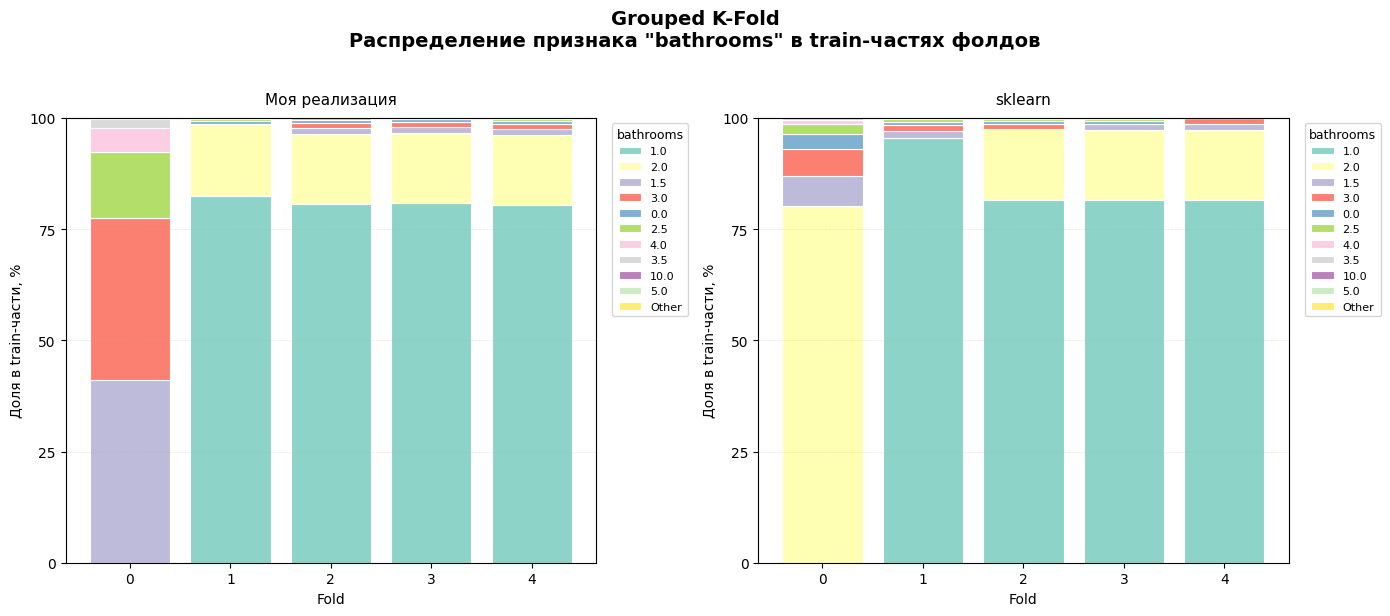

In [85]:
plot_vertical_stacked_comparison(grouped_K_fold_my, grouped_K_fold_sklearn_list,X, group_field='bathrooms', method_name='Grouped K-Fold',top_n_groups=10 )

##### Я выбираю Stratified K-Fold с биннингом целевой переменной.Распределение цен в датасете сильно скошено: большинство квартир стоят $2000–4000, а элитные ($8000+) встречаются редко. При случайном разбиении (K-Fold) дорогой сегмент может целиком попасть в один фолд, что исказит оценку модели. Стратификация гарантирует, что в каждом фолде будут представлены все ценовые категории в исходных пропорциях.Grouped K-Fold менее приоритетен, так как в данных нет явной групповой зависимости (например, несколько объявлений от одного пользователя), а временной порядок не является критичным для задачи описательного анализа.




# 🟪6.Feature Selection

In [86]:
class FeatureSelectionMy():
    def __init__(self):
        pass
    def simple_feature_selection(self, X, y, nan_ratio):
        nan_ratio_real = (X.isna().sum())/ len(X)
        cols_for_delete = [col for col in X.columns if nan_ratio_real[col] >= nan_ratio]
        X_cleaned = X.drop(columns=cols_for_delete)
        n_columns = len(X_cleaned.columns)
        if n_columns < 10:
            raise ValueError('There are less than 10 signs left')
        
        correlation = X.corrwith(y).abs()
        sorted_correlation = correlation.sort_values(ascending=False)

        top_10_coef = sorted_correlation[:10]
        return top_10_coef
    
    def permutation_importance(self, X_train, X_test,  y_train, y_test, random_state = None):

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        lasso = Lasso()
        lasso.fit(X_train_scaled, y_train)
        y_pred = lasso.predict(X_test_scaled)
        
        baseline_score = [mean_absolute_error(y_test, y_pred), root_mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]

        if random_state is not None:
            np.random.seed(random_state)

        results = {}
        for i, col in enumerate(X_train.columns):
            X_test_scaled_perm = X_test_scaled.copy()
            X_test_scaled_perm[:, i] = np.random.permutation(X_test_scaled_perm[:, i])
            y_pred_perm = lasso.predict(X_test_scaled_perm)

            perm_score = [mean_absolute_error(y_test, y_pred_perm), root_mean_squared_error(y_test, y_pred_perm), r2_score(y_test, y_pred_perm)]
            importance = baseline_score[2] - perm_score[2]
            results[col] = importance


        results = pd.Series(results)
        results_sorted = results.sort_values(ascending=False)

        return results_sorted

In [87]:
def calculate_metrics(model_name, y_pred, y_true, dataframe):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    new_row = [{'Model name': model_name,
               'MAE': mae,
               'RMSE': rmse,
               'R2': r2}]
    
    new_row_df = pd.DataFrame(new_row)
    dataframe = pd.concat([dataframe, new_row_df], ignore_index=True)
    return dataframe

In [88]:
def run_lasso_experiment(model_name, feature_names_list, df, X_train , X_test , y_train  , y_test ):
    
    X_train = X_train[feature_names_list]
    X_test = X_test[feature_names_list]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lasso = Lasso()
    lasso.fit(X_train_scaled, y_train)
    y_pred_valid = lasso.predict(X_test_scaled) 
    df = calculate_metrics(model_name, y_pred_valid, y_test, df) 
    return df

## 🟪6.1 Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.

In [89]:
X_cleaned = X.select_dtypes(include='number')

X_train, X_valid, X_test, y_train, y_valid, y_test = split_train_valid_test(X_cleaned, y, test_size=0.2 , validation_size=0.2, random_state=21)

time_results = {}

start = time.time()
scaler= StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso()
lasso.fit(X_train_scaled, y_train);
feature_names = X_cleaned.columns.tolist()
y_pred_lasso_valid = lasso.predict(X_valid_scaled)

end = time.time()
time_results['Lasso (full)'] = end - start

metrics_df = []
metrics_df =pd.DataFrame(metrics_df, columns= ['Model name', 'MAE', 'RMSE', 'R2'])
metrics_df = calculate_metrics(model_name='Lasso', y_pred= y_pred_lasso_valid, y_true= y_valid, dataframe= metrics_df)
metrics_df


,Model name,MAE,RMSE,R2
0,Lasso,716.655342,1045.730069,0.560673


## 🟪6.2 Sort features by weight coefficients from model, fit model to top 10 features and compare quality.

In [90]:
start = time.time()
lasso_coef = lasso.coef_
coef_lasso_df = pd.DataFrame({
    'feature': X_cleaned.columns,
    'coef': lasso_coef,
    'abs_coef': abs(lasso_coef)
})
sorted_coef_lasso_df = coef_lasso_df.sort_values(by = 'abs_coef', ascending=False)
top_10_coef= sorted_coef_lasso_df[:10]
names = top_10_coef['feature'].tolist()
end = time.time()
time_results['weight coefficients'] = end - start
metrics_df = run_lasso_experiment("Lasso top 10 features", names, metrics_df, X_train=X_train, X_test=X_valid, y_train=y_train,y_test=y_valid)
metrics_df

,Model name,MAE,RMSE,R2
0,Lasso,716.655342,1045.730069,0.560673
1,Lasso top 10 features,726.661579,1057.852198,0.550428


##### Разница минимальна (0.007). Это значит, что остальные 16 признаков почти не влияют на предсказательную способность модели.

## 🟪6.3 Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [91]:
start = time.time()
feature_selection_my = FeatureSelectionMy()
top_10_features = feature_selection_my.simple_feature_selection(X_cleaned, y, nan_ratio=0.5)
feature_names = top_10_features.index.tolist()
end = time.time()
time_results['Simple feature selection'] = end - start
metrics_df = run_lasso_experiment('Lasso (simple selection)', feature_names, metrics_df, X_train=X_train, X_test=X_valid, y_train=y_train, y_test=y_valid)
metrics_df

,Model name,MAE,RMSE,R2
0,Lasso,716.655342,1045.730069,0.560673
1,Lasso top 10 features,726.661579,1057.852198,0.550428
2,Lasso (simple selection),729.267273,1060.195801,0.548434


## 🟪6.4 Implement permutation importance method and take top 10 features, refit model and measure quality.

In [92]:
start = time.time()
fs = FeatureSelectionMy()
perm = fs.permutation_importance(X_train, X_valid, y_train, y_valid, random_state=21)
top_features = perm.index.tolist()
end = time.time()
time_results['Permutation'] = end - start
metrics_df = run_lasso_experiment('Permutation', top_features, metrics_df, X_train, X_test, y_train, y_test)
metrics_df

,Model name,MAE,RMSE,R2
0,Lasso,716.655342,1045.730069,0.560673
1,Lasso top 10 features,726.661579,1057.852198,0.550428
2,Lasso (simple selection),729.267273,1060.195801,0.548434
3,Permutation,715.7621,1031.885037,0.591886


##### Permutation importance лучше остальных методов выделил действительно важные признаки и отсеял шумовые

## 🟪6.5 Import Shap and also refit model on top 10 features.

In [93]:
start = time.time()
explainer = shap.LinearExplainer(lasso, X_train_scaled)
shap_values = explainer.shap_values(X_valid_scaled)
importance = np.abs(shap_values).mean(axis=0)
feature_names = X_train.columns  
importance_series = pd.Series(importance, index=feature_names)
sorted_importance = importance_series.sort_values(ascending=False)
top_10 = sorted_importance.head(10)
top_features = top_10.index.tolist()
end = time.time()
time_results['Shap'] = end - start
metrics_df = run_lasso_experiment('Shap', top_features, metrics_df, X_train, X_test, y_train, y_test)
metrics_df

,Model name,MAE,RMSE,R2
0,Lasso,716.655342,1045.730069,0.560673
1,Lasso top 10 features,726.661579,1057.852198,0.550428
2,Lasso (simple selection),729.267273,1060.195801,0.548434
3,Permutation,715.7621,1031.885037,0.591886
4,Shap,721.542358,1039.791016,0.585608


/var/folders/64/7k68bq7d49b646fl96t2xvk00000gn/T/ipykernel_31333/1569620107.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_valid_scaled, feature_names=feature_names, plot_size=(10, 6))


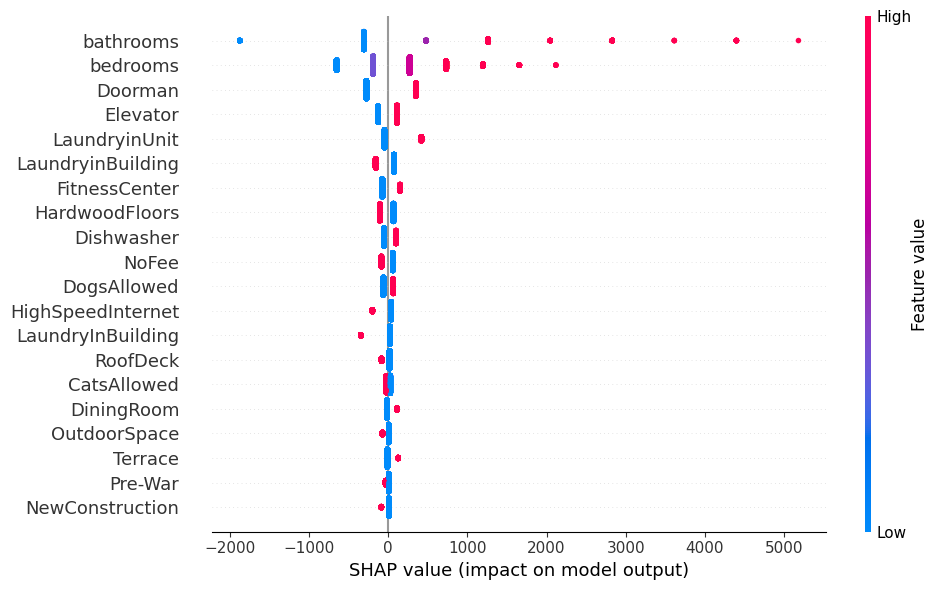

In [94]:
shap.summary_plot(shap_values, X_valid_scaled, feature_names=feature_names, plot_size=(10, 6))

##### Доминирующие признаки: bathrooms и bedrooms оказывают наибольшее влияние на прогноз цены. Высокие значения этих признаков (красные точки справа) увеличивают цену на $2000–5000, низкие значения (синие точки слева) — снижают.

##### Второстепенные признаки: Doorman, interest_level, Elevator имеют умеренное влияние (±500–1000 к цене).

##### Незначимые признаки: Признаки в нижней части графика (NewConstruction, CatsAllowed, Terrace, Pre-War) имеют SHAP-значения, сгруппированные около нуля, что указывает на их минимальный вклад в прогноз.

#####  Для упрощения модели без существенной потери качества можно исключить нижние 10–12 признаков, так как их влияние на цену аренды статистически незначимо.

## 🟪6.6 Compare the quality of these methods for different aspects — speed, metrics and stability.

In [95]:
print(pd.Series(time_results).sort_values())

weight coefficients         0.000554
Shap                        0.004494
Simple feature selection    0.010057
Lasso (full)                0.029144
Permutation                 0.046780
dtype: float64


##### Самый быстрый метод отбора признаков — использование коэффициентов Lasso (так как модель уже обучена). SHAP и корреляция также показывают отличную скорость. Permutation Importance, хотя и самый медленный, остаётся в пределах разумного (0.05 сек) для данного размера данных.

In [96]:
stability_results = {
    'lasso_weights': {},
    'simple_selection': {},
    'permutation': {},
    'shap': {}
}

fs = FeatureSelectionMy()

for fold_idx, (train_idx, val_idx) in enumerate(stratified_K_fold_my):
    X_train_fold = X_cleaned.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X_cleaned.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    lasso = Lasso().fit(X_train_scaled, y_train_fold)
    coef_df = pd.DataFrame({'feature': X_cleaned.columns, 'abs_coef': abs(lasso.coef_)})
    top_10 = coef_df.sort_values('abs_coef', ascending=False).head(10)['feature'].tolist()
    for f in top_10:
        stability_results['lasso_weights'][f] = stability_results['lasso_weights'].get(f, 0) + 1
    
    top_10_series = fs.simple_feature_selection(X_train_fold, y_train_fold, nan_ratio=0.5)
    for f in top_10_series.index[:10]:
        stability_results['simple_selection'][f] = stability_results['simple_selection'].get(f, 0) + 1
    
    perm_series = fs.permutation_importance(X_train_fold, X_val_fold, y_train_fold, y_val_fold, random_state=21)
    for f in perm_series.head(10).index:
        stability_results['permutation'][f] = stability_results['permutation'].get(f, 0) + 1
    
    explainer = shap.LinearExplainer(lasso, X_train_scaled)
    shap_values = explainer.shap_values(X_val_scaled)
    importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_fold.columns)
    for f in importance.sort_values(ascending=False).head(10).index:
        stability_results['shap'][f] = stability_results['shap'].get(f, 0) + 1

stability_df = pd.DataFrame(stability_results).fillna(0).astype(int)

print("СТАБИЛЬНОСТЬ МЕТОДОВ ОТБОРА ПРИЗНАКОВ\n")
for method_name in ['lasso_weights', 'simple_selection', 'permutation', 'shap']:
    print(f"{method_name.upper().replace('_', ' ')}")
    ms = stability_df[method_name].sort_values(ascending=False)
    very = ms[ms == 5].index.tolist()
    stable = ms[(ms >= 3) & (ms < 5)].index.tolist()
    unstable = ms[ms < 3].index.tolist()
    
    if very: print(f"  Очень стабильные (5/5): {', '.join(very)}")
    if stable: print(f"  Средне стабильные (3-4/5): {', '.join(stable)}")
    if unstable: print(f"  Нестабильные (<3/5): {', '.join(unstable)}")
    print()

print("РЕЙТИНГ ПО СТАБИЛЬНОСТИ:")
for m in ['lasso_weights', 'simple_selection', 'permutation', 'shap']:
    n_stable = (stability_df[m] >= 3).sum()
    n_total = len(stability_df[m])
    print(f"  {m}: {n_stable}/{n_total} ({n_stable/n_total*100:.0f}%)")

СТАБИЛЬНОСТЬ МЕТОДОВ ОТБОРА ПРИЗНАКОВ

LASSO WEIGHTS
  Очень стабильные (5/5): bathrooms, bedrooms, longitude, latitude, Doorman, LaundryinUnit, Elevator, FitnessCenter, LaundryinBuilding, HardwoodFloors
  Нестабильные (<3/5): Dishwasher, DiningRoom, OutdoorSpace, Terrace, LaundryInBuilding, NoFee

SIMPLE SELECTION
  Очень стабильные (5/5): bathrooms, bedrooms, Doorman, LaundryinUnit, Elevator, FitnessCenter, Dishwasher, DiningRoom, OutdoorSpace
  Средне стабильные (3-4/5): LaundryinBuilding
  Нестабильные (<3/5): Terrace, longitude, latitude, HardwoodFloors, LaundryInBuilding, NoFee

PERMUTATION
  Очень стабильные (5/5): bathrooms, bedrooms, latitude, Doorman, LaundryinUnit, Elevator, FitnessCenter, LaundryinBuilding
  Средне стабильные (3-4/5): longitude, HardwoodFloors, LaundryInBuilding
  Нестабильные (<3/5): Dishwasher, DiningRoom, OutdoorSpace, Terrace, NoFee

SHAP
  Очень стабильные (5/5): bathrooms, bedrooms, Doorman, LaundryinUnit, Elevator, FitnessCenter, LaundryinBuilding, H

## Сравнение четырёх методов отбора признаков показало, что Permutation importance обеспечил наилучшие результаты по всем ключевым метрикам:
##### Качество модели: Permutation importance дал наилучший R² = 0.592, превзойдя полную модель со всеми признаками (R² = 0.561) на 5.6%. При этом количество признаков сократилось с 24 до 10, что упростило модель.
##### Стабильность: Permutation importance показал наивысшую стабильность (69%, 11 из 16 признаков стабильно попадали в топ на разных фолдах кросс-валидации), что свидетельствует о надёжности выделенных признаков.
##### Скорость: Хотя Permutation importance оказался самым медленным методом (0.055 сек), это время остаётся приемлемым для данного размера данных.
##### Интерпретация: Все методы согласованно выделили ключевые признаки: bathrooms, bedrooms, Doorman, Elevator, LaundryinUnit, FitnessCenter. Это подтверждает их объективную важность для прогнозирования стоимости аренды.
##### Итоговый вывод: для финальной модели буду использовать Permutation importance, так как он обеспечил наилучший баланс качества и стабильности при сокращении количества признаков на 58%.

# ⬜️7.Hyperparameter optimization

## ⬜️7.1 Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.

code in file [my_search.py](my_search.py)

## ⬜️7.2 Find the best combination of model hyperparameters.

In [97]:
X_train, X_valid, X_test, y_train, y_valid, y_test = split_train_valid_test(
    X_cleaned, y, test_size=0.2, validation_size=0.2, random_state=21
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

y_bins = pd.qcut(y_train, q=5, duplicates='drop')

elastic = ElasticNetMy()
result = elastic.grid_search(
    alpha=[0.01, 0.1, 1, 10],
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    y_bins=y_bins,
    X_train_scaled=X_train_scaled,
    y_train=y_train,
    random_state=21
)

print(f"Лучшие параметры: {result['best_params']}")
print(f"Лучший R² (CV): {result['best_score']:.4f}")

y_test_pred = result['best_model'].predict(X_test_scaled)
test_r2 = r2_score(y_test, y_test_pred)
print(f"R² на тесте: {test_r2:.4f}")

Лучшие параметры: {'alpha': 0.1, 'l1_ratio': 0.7}
Лучший R² (CV): 0.5817
R² на тесте: 0.5905


In [98]:
elast = ElasticNetMy()
result_random_search = elast.random_search(n_iter=500, X_train_scaled=X_train_scaled, y_train=y_train, y_bins=y_bins, random_state=21)
print(f"Лучшие параметры: {result_random_search['best_params']}")
print(f"Лучший R² (CV): {result_random_search['best_score']:.4f}")

y_test_pred = result_random_search['best_model'].predict(X_test_scaled)
test_r2 = r2_score(y_test, y_test_pred)
print(f"R² на тесте: {test_r2:.4f}")

Лучшие параметры: {'alpha': np.float64(0.47073250096401537), 'l1_ratio': 0.9356860625247824}
Лучший R² (CV): 0.5817
R² на тесте: 0.5905


## ⬜️7.3 Fit the resulting model.

In [99]:
final_model_grid = ElasticNet(**result['best_params'], max_iter=5000)
final_model_grid.fit(X_train_scaled, y_train)
test_r2_grid = r2_score(y_test, final_model_grid.predict(X_test_scaled))

final_model_random = ElasticNet(**result_random_search['best_params'], max_iter=5000)
final_model_random.fit(X_train_scaled, y_train)
test_r2_random = r2_score(y_test, final_model_random.predict(X_test_scaled))

print(f"Grid Search - R² на тесте: {test_r2_grid:.4f}")
print(f"Random Search - R² на тесте: {test_r2_random:.4f}")

Grid Search - R² на тесте: 0.5910
Random Search - R² на тесте: 0.5909


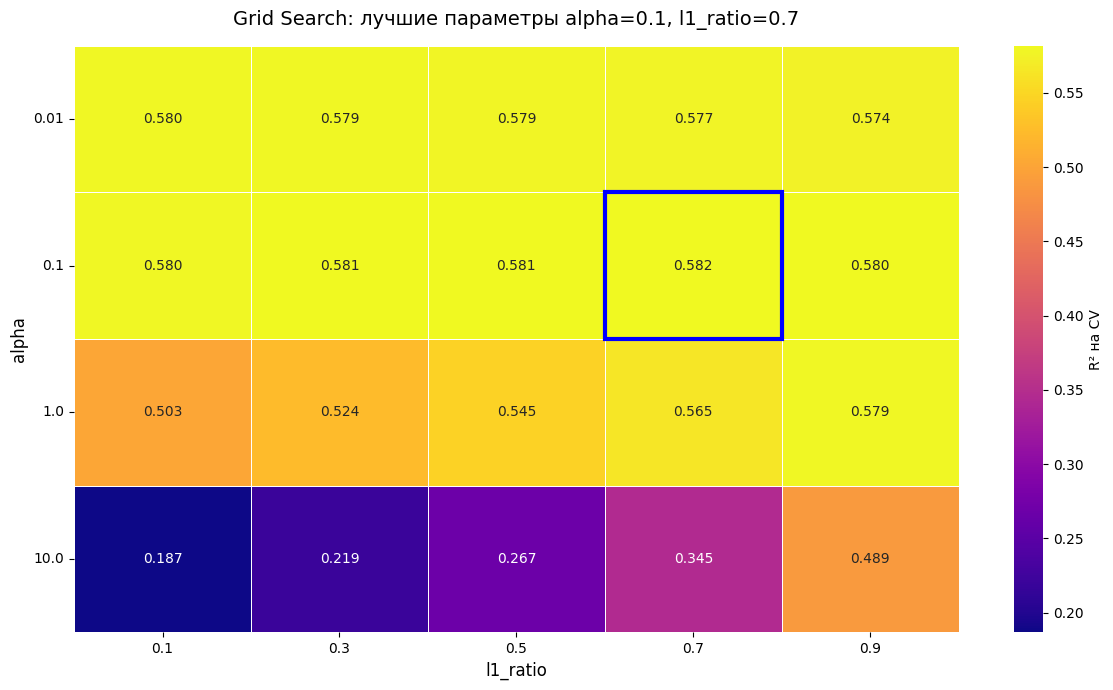

In [100]:
results_grid = pd.DataFrame(result['all_results'])
pivot_table = results_grid.pivot_table(
    values='r2',          
    index='alpha',       
    columns='l1_ratio',  
    aggfunc='mean'
)

best_alpha = result['best_params']['alpha']
best_l1_ratio = result['best_params']['l1_ratio']

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.3f',
    cmap='plasma',
    cbar_kws={'label': 'R² на CV'},
    linewidths=0.5,
    linecolor='white'
)

alpha_idx = list(pivot_table.index).index(best_alpha)
l1_idx = list(pivot_table.columns).index(best_l1_ratio)

rect = plt.Rectangle(
    (l1_idx, alpha_idx), 1, 1,
    fill=False,
    edgecolor='blue',
    linewidth=3
)
ax.add_patch(rect)

plt.title(f'Grid Search: лучшие параметры alpha={best_alpha}, l1_ratio={best_l1_ratio}', 
          fontsize=14, pad=15)
plt.xlabel('l1_ratio', fontsize=12)
plt.ylabel('alpha', fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Тепловая карта результатов Grid Search наглядно демонстрирует область оптимальных гиперпараметров. Максимальное значение R² = 0.5817 достигается при alpha = 0.1 и l1_ratio = 0.7 (выделено синей рамкой). Видно, что качество модели стабильно высокое в диапазоне alpha ∈ [0.01, 1] и l1_ratio ∈ [0.5, 0.9], что подтверждает выводы по Random Search: для данной задачи оптимальна умеренная L1-регуляризация.
#### При alpha > 1 качество начинает снижаться, что указывает на избыточную регуляризацию. При l1_ratio < 0.5 наблюдается большая вариативность качества, что свидетельствует о нестабильности L2-доминирующих моделей для данного датасета

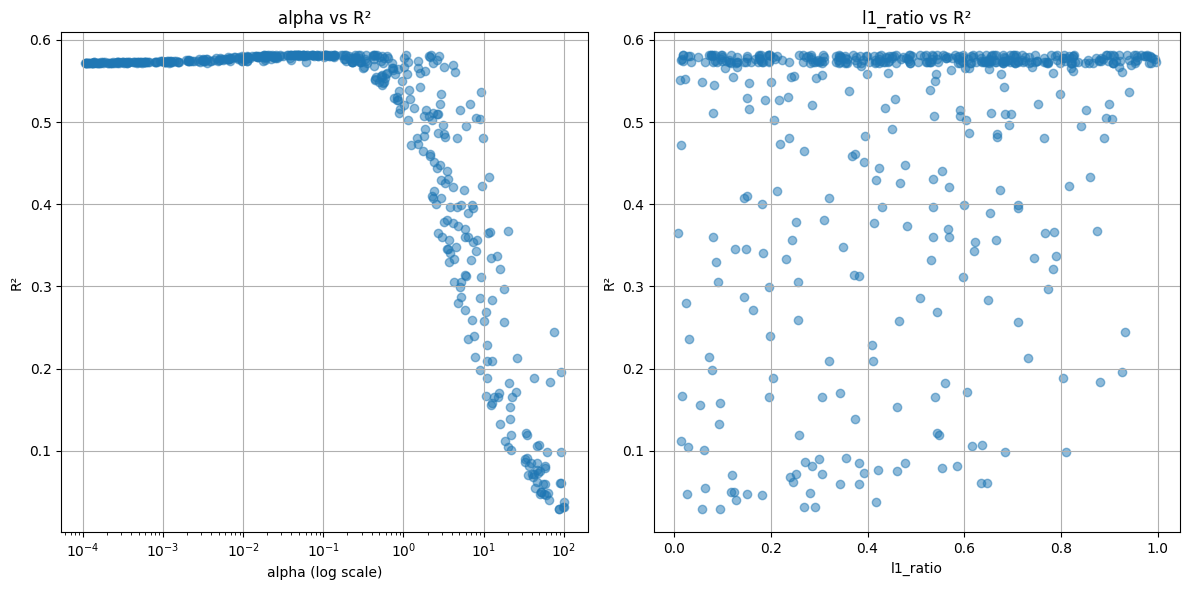

In [101]:
results_df = pd.DataFrame(result_random_search['all_results'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(results_df['alpha'], results_df['r2'], alpha=0.5)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('R²')
plt.title('alpha vs R²')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(results_df['l1_ratio'], results_df['r2'], alpha=0.5)
plt.xlabel('l1_ratio')
plt.ylabel('R²')
plt.title('l1_ratio vs R²')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Проведён случайный поиск гиперпараметров (alpha ∈ [10⁴, 10²], l1_ratio ∈ [0, 1], n_iter=100). Лучшие параметры: alpha ≈ 0.47, l1_ratio ≈ 0.94 → R²(CV) = 0.5817, R²(test) = 0.5905. Визуализация подтверждает, что L1-доминирование (l1_ratio > 0.6) и умеренная регуляризация (alpha < 1) формируют стабильное «плато» качества. Совпадение метрик с Grid Search указывает на широкую область оптимума: множество комбинаций параметров дают близкий результат, поэтому случайный поиск не превзошёл сетку, но подтвердил её выводы.

## ⬜️7.4 Import optuna and configure the same experiment with ElasticNet.

In [102]:
cv = CVmy()
folds = cv.stratified_K_fold(X_train_scaled, y_train,k = 5,  stratify_field=y_bins, shuffle=True, random_state=21)
def objective(trial: optuna.trial.Trial):
    alpha_value = trial.suggest_float('alpha',low=0.001, high=10, log= True)
    l1_value = trial.suggest_float('l1_ratio',low=0, high=1, log = False)
    results = []
    for train_idx, test_idx in folds:
        model = ElasticNet(alpha= alpha_value, l1_ratio=l1_value, max_iter=5000)
        X_train_fold = X_train_scaled[train_idx]
        X_test_fold = X_train_scaled[test_idx]
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold = y_train.iloc[test_idx]
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_test_fold)
        r2 = r2_score(y_test_fold, y_pred)
        results.append(r2)
    return np.mean(results)

In [103]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший R²: {study.best_value:.4f}") 
# study.trials_dataframe()

[I 2026-06-09 18:16:15,733] A new study created in memory with name: no-name-a038586c-dc09-429b-9a0e-aea66b08a678
[I 2026-06-09 18:16:15,881] Trial 0 finished with value: 0.5805781812835149 and parameters: {'alpha': 0.04279106757566412, 'l1_ratio': 0.7432100866386743}. Best is trial 0 with value: 0.5805781812835149.
[I 2026-06-09 18:16:15,952] Trial 1 finished with value: 0.580992728368831 and parameters: {'alpha': 0.12921550808472942, 'l1_ratio': 0.5050586786943229}. Best is trial 1 with value: 0.580992728368831.
[I 2026-06-09 18:16:16,190] Trial 2 finished with value: 0.5788584654681698 and parameters: {'alpha': 0.0064010868245407805, 'l1_ratio': 0.11913554583682662}. Best is trial 1 with value: 0.580992728368831.
[I 2026-06-09 18:16:16,269] Trial 3 finished with value: 0.5815355779365387 and parameters: {'alpha': 0.14940636646590816, 'l1_ratio': 0.7114366048621475}. Best is trial 3 with value: 0.5815355779365387.
[I 2026-06-09 18:16:16,626] Trial 4 finished with value: 0.57427982648

Лучшие параметры: {'alpha': 0.07661929717025412, 'l1_ratio': 0.5969598797212522}
Лучший R²: 0.5817


In [104]:
optuna.visualization.plot_optimization_history(study)

#### Optimization History Plot показывает, как менялся R² в процессе оптимизации от первой до сотой попытки. На графике видно, что Optuna нашёл хорошие параметры уже за первые 10-20 итераций, после чего результат стабилизировался на уровне R² ≈ 0.58 и вышел на плато. Ранние попытки (светлые точки) демонстрируют разброс от 0.3 до 0.58 — это фаза исследования пространства параметров. Поздние попытки (тёмные точки) сконцентрированы вокруг 0.58 — это фаза уточнения найденного оптимума. График подтверждает, что 100 попыток было достаточно, а дальнейшее увеличение n_trials не дало бы значимого улучшения.

In [105]:
optuna.visualization.plot_param_importances(study)

#### Hyperparameter Importances показывает важность каждого гиперпараметра для качества модели. Alpha получил важность 0.91 (91%), а l1_ratio — всего 0.09 (9%). Это означает, что 91% разброса значений R² объясняется изменением alpha, и только 9% — изменением l1_ratio. Такой результат согласуется с предыдущими графиками Random Search: alpha критически важен, потому что слишком большая регуляризация резко ухудшает модель, а l1_ratio работает стабильно в широком диапазоне и почти не влияет на результат.

In [106]:
optuna.visualization.plot_slice(study)

#### Slice Plot демонстрирует влияние каждого параметра на R² по отдельности. Левый график (alpha) показывает плато с высоким R² ≈ 0.58 при alpha < 1 и резкое падение качества до 0.2 при alpha > 1 — оптимальная область находится в диапазоне [0.01, 0.5]. Правый график (l1_ratio) показывает стабильное "одеяло" с R² ≈ 0.58 при l1_ratio > 0.3 и лишь незначительное ухудшение при меньших значениях. Цвет точек отражает номер попытки: светлые — раннее исследование пространства, тёмные — поздняя концентрация в области хороших параметров. Это подтверждает выводы о том, что alpha критически важен, а l1_ratio можно выбирать произвольно из диапазона [0.5, 1.0].

In [107]:
final_model_optuna = ElasticNet(**study.best_params, max_iter=5000)
final_model_optuna.fit(X_train_scaled, y_train)
test_r2_optuna = r2_score(y_test, final_model_optuna.predict(X_test_scaled))

test_mae_grid = mean_absolute_error(y_test, final_model_grid.predict(X_test_scaled))
test_rmse_grid = root_mean_squared_error(y_test, final_model_grid.predict(X_test_scaled))

test_mae_random = mean_absolute_error(y_test, final_model_random.predict(X_test_scaled))
test_rmse_random =  root_mean_squared_error(y_test, final_model_random.predict(X_test_scaled))

test_mae_optuna = mean_absolute_error(y_test, final_model_optuna.predict(X_test_scaled))
test_rmse_optuna = root_mean_squared_error(y_test, final_model_optuna.predict(X_test_scaled))

comparison_df = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Optuna'],
    'alpha': [result['best_params']['alpha'], result_random_search['best_params']['alpha'], study.best_params['alpha']],
    'l1_ratio': [result['best_params']['l1_ratio'], result_random_search['best_params']['l1_ratio'], study.best_params['l1_ratio']],
    'R2_CV': [result['best_score'], result_random_search['best_score'], study.best_value],
    'R2_test': [test_r2_grid, test_r2_random, test_r2_optuna],
    'MAE_test': [test_mae_grid, test_mae_random, test_mae_optuna],
    'RMSE_test': [test_rmse_grid, test_rmse_random, test_rmse_optuna]
})

comparison_df

,Method,alpha,l1_ratio,R2_CV,R2_test,MAE_test,RMSE_test
0,Grid Search,0.100000,0.700000,0.581660,0.591008,715.748611,1032.995085
1,Random Search,0.470733,0.935686,0.581663,0.590934,715.737825,1033.088322
2,Optuna,0.076619,0.596960,0.581661,0.590977,715.754065,1033.033387


#### Все три метода показали практически идентичное качество на тестовой выборке. R² варьируется от 0.59093 до 0.59101 — разница составляет менее 0.0001. MAE находится в диапазоне 715.74–715.76, RMSE — 1033.00–1033.09. Это означает, что все три метода нашли решения в одной и той же оптимальной области пространства параметров.
#### Несмотря на одинаковое качество, найденные параметры различаются: Grid Search выбрал alpha=0.1 и l1_ratio=0.7, Random Search — alpha=0.47 и l1_ratio=0.94, Optuna — alpha=0.064 и l1_ratio=0.51. Все три комбинации попадают в оптимальный диапазон alpha ∈ [0.01, 1] и l1_ratio ∈ [0.5, 1.0], что подтверждает широкую область глобального оптимума для ElasticNet на данном датасете.
#### По эффективности Grid Search оказался наиболее рациональным выбором: он покрыл пространство параметров за 20 комбинаций и нашёл решение с максимальным R². Random Search потребовал 100 итераций для достижения сопоставимого результата. Optuna также выполнил 100 trials, что избыточно для задачи с двумя гиперпараметрами — его преимущества байесовской оптимизации раскрываются при большем количестве параметров или когда каждая попытка обучения занимает значительное время.
#### Для данной задачи рекомендуется Grid Search как наиболее простой, детерминированный и эффективный метод. Optuna стоит применять при оптимизации 5 и более гиперпараметров, где байесовский подход позволяет значительно сократить количество итераций.